In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import time
import matplotlib.pyplot as plt
import matplotlib as mpl
import argparse
import json

from src.data.place_cells import PlaceCells
from src.data.trajectory_generator import TrajectoryGenerator
from src.model import RNN, HierarchicalPCN, TemporalPCN
from src.trainer import Trainer, PCTrainer
from src.visualize import *
import src.utils as utils
from pypalettes import load_cmap

import pandas as pd
import seaborn as sns

## MISC

In [2]:
import math
def circle_mask1(size, radius, in_val=1.0, out_val=0.0):
    """Calculating the grid scores with different radius."""
    sz = [math.floor(size[0] / 2), math.floor(size[1] / 2)]
    x = np.linspace(-sz[0], sz[1], size[1])
    x = np.expand_dims(x, 0)
    x = x.repeat(size[0], 0)
    y = np.linspace(-sz[0], sz[1], size[1])
    y = np.expand_dims(y, 1)
    y = y.repeat(size[1], 1)
    z = np.sqrt(x**2 + y**2)
    z = np.less_equal(z, radius)
    vfunc = np.vectorize(lambda b: b and in_val or out_val)
    return vfunc(z)

def circle_mask2(shape, radius):
    """Generates a circular mask with the given radius."""
    y, x = np.ogrid[:shape[0], :shape[1]]
    center_y, center_x = shape[0] // 2, shape[1] // 2
    distance = np.sqrt((x - center_x)**2 + (y - center_y)**2)
    mask = distance <= radius
    return mask.astype(float)

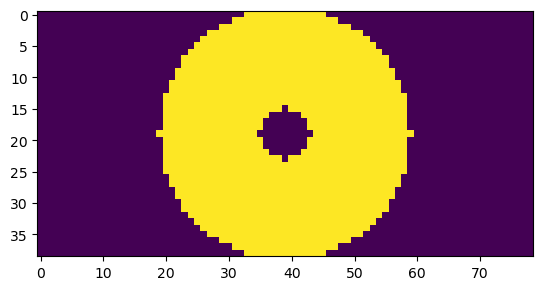

In [3]:
plt.imshow(circle_mask2((39, 79), 20) * (1 - circle_mask2((39, 79), 4)))

In [8]:
sq_scores = np.load('../results/tpc/Jan-23-2025-10-32-41/grid_scores.npy')
tr_scores = np.load('../results/tpc/Jan-23-2025-11-20-40/grid_scores.npy')

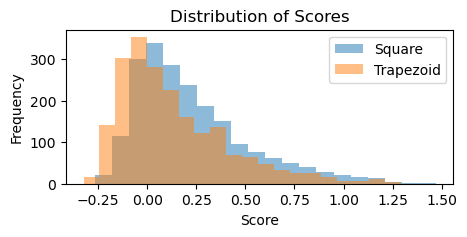

In [9]:
plt.figure(figsize=(5, 2))
plt.hist(sq_scores, bins=20, alpha=0.5, label='Square')
plt.hist(tr_scores, bins=20, alpha=0.5, label='Trapezoid')
plt.legend()
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of Scores')
plt.show()

In [6]:
tpc_scores = np.load('../results/tpc/Jan-23-2025-18-07-53/grid_scores.npy')
rnn_scores = np.load('../results/rnn/Jan-23-2025-10-58-46/grid_scores.npy')

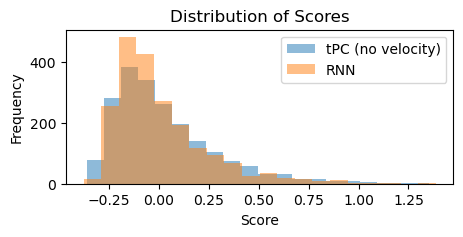

In [8]:
# violin plots of scores
plt.figure(figsize=(5, 2))
plt.hist(tpc_scores, bins=20, alpha=0.5, label='tPC (no velocity)')
plt.hist(rnn_scores, bins=20, alpha=0.5, label='RNN')
plt.legend()
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of Scores')
plt.show()

In [11]:
np.mean(tpc_scores), np.mean(rnn_scores)

(0.12594252450112184, 0.0033520618915886535)

## Basics

In [4]:
class Options:
    def __init__(self):
        self.device = 'cpu'
        self.oned = False
        self.Np = 512
        self.Ng = 2048
        self.Nv = 2
        self.DoG = True
        self.box_width = 1.4
        self.box_height = 1.4
        self.place_cell_rf = 0.12
        self.surround_scale = 2
        self.periodic = False
        self.sequence_length = 10
        self.dt = 0.02
        self.batch_size = 500
        self.n_epochs = 120
        self.n_steps = 100
        self.learning_rate = 1e-4
        self.weight_decay = 1e-4
        self.decay_step_size = 50
        self.decay_rate = 0.9
        self.lambda_z = 0
        self.lambda_z_init = 0
        self.inf_iters = 20
        self.test_inf_iters = 20
        self.inf_lr = 2e-2
        self.out_activation = 'softmax'
        self.rec_activation = 'relu'
        self.restore = None
        self.preloaded_data = False
        self.save = True
        self.save_every = 50
        self.loss = 'CE'
        self.normalize_pc = 'softmax'
        self.is_wandb = False
        self.sweep = False
        self.mode = 'train'
        self.no_velocity = False
        self.truncating = 1

    def load_from_json(self, json_file):
        with open(json_file, 'r') as file:
            data = json.load(file)
        
        # Set attributes from JSON, skip `_get_args` and `_get_kwargs`
        for key, value in data.items():
            if hasattr(self, key):
                setattr(self, key, value)

    def print_values(self):
        for key, value in self.__dict__.items():
            print(f'{key}: {value}')

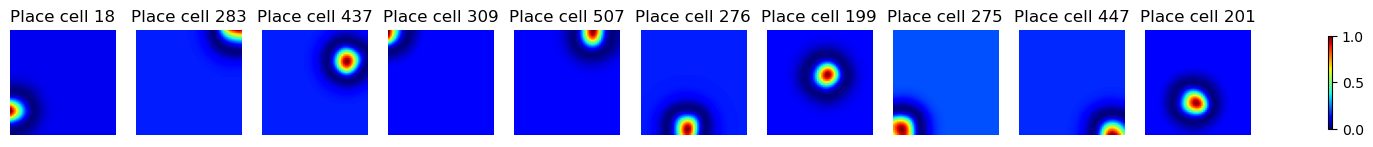

In [5]:
def plot_place_cells(place_cell, options, res, n_show=5):
    grid = np.array(
        np.meshgrid(
            np.linspace(-options.box_width/2, options.box_width/2, res),
            np.linspace(-options.box_height/2, options.box_height/2, res)
        )
    ).T
    grid = torch.tensor(grid, device=options.device)
    grid_pc = place_cell.get_activation(grid)
    select = np.random.choice(np.arange(options.Np), n_show, replace=False)
    fig, axes = plt.subplots(1, n_show, figsize=(n_show*2, 2))
    for i in range(n_show):
        # notice the interpolation arg, which visually makes these 'real' place fields
        pc = grid_pc[:,:,select[i]].cpu().numpy()
        # normalize to [0, 1]
        pc = (pc - pc.min()) / (pc.max() - pc.min())
        im = axes[i].imshow(pc, cmap='jet')
        axes[i].set_title('Place cell {}'.format(select[i]))
        axes[i].axis('off')
    fig.colorbar(im, ax=axes.ravel().tolist(), orientation='vertical', shrink=0.6)
    plt.show()

options = Options()
place_cell = PlaceCells(options)
plot_place_cells(place_cell, options, 55, n_show=10)

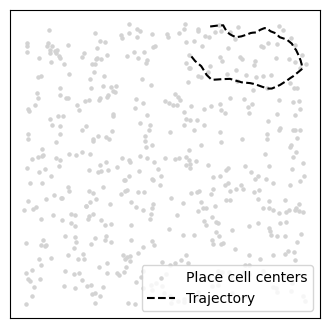

In [7]:
options.sequence_length = 70
trajectory_generator = TrajectoryGenerator(options, place_cell)
inputs, _, pos = trajectory_generator.get_test_batch()
centers = place_cell.centers.cpu()
pos = pos.cpu()
plt.figure(figsize=(4,4))
plt.scatter(centers[:,0], centers[:,1], c='lightgrey', label='Place cell centers', s=5)
for i in range(1):
    plt.plot(pos[i,:,0],pos[i,:,1], label='Trajectory', c='k', ls='--')
    if i==0:
        plt.legend()
plt.xticks([])
plt.yticks([])
# plt.savefig('figures/trjectory.pdf', bbox_inches='tight')
plt.show()

In [18]:
def get_trajetories(tpc_path, rnn_path):
    options_tpc = Options()
    options_rnn = Options()
    tpc_path = os.path.join('../results', 'tpc', tpc_path)
    options_tpc.load_from_json(os.path.join(tpc_path, 'configs.json'))
    ckpt_tpc = torch.load(os.path.join(tpc_path, 'models', 'most_recent_model.pth'), map_location=torch.device(options.device))
    options_tpc.save_dir = tpc_path

    rnn_path = os.path.join('../results', 'rnn', rnn_path)
    options_rnn.load_from_json(os.path.join(rnn_path, 'configs.json'))
    ckpt_rnn = torch.load(os.path.join(rnn_path, 'models', 'most_recent_model.pth'), map_location=torch.device(options.device))
    options_rnn.save_dir = rnn_path

    place_cell = PlaceCells(options_tpc)
    generator = TrajectoryGenerator(options_tpc, place_cell)

    tpc = TemporalPCN(options_tpc).to(options_tpc.device)
    init_model = HierarchicalPCN(options_tpc).to(options_tpc.device)
    tpc.load_state_dict(ckpt_tpc['model'])
    init_model.load_state_dict(ckpt_tpc['init_model'])
    pc_trainer = PCTrainer(options_tpc, tpc, init_model, generator, place_cell, restore=False)

    rnn = RNN(options_rnn, place_cell).to(options_rnn.device)
    rnn.load_state_dict(ckpt_rnn)
    rnn_trainer = Trainer(options_rnn, rnn, generator, place_cell, restore=False)

    # Generate trajectories (one batch)
    inputs, _, pos_batch = generator.get_test_batch()
    pred_rnn, _ = rnn_trainer.predict(inputs)
    pred_rnn = place_cell.get_nearest_cell_pos(F.softmax(pred_rnn.detach(), dim=-1)).detach().cpu().numpy()
    pred_tpc, _ = pc_trainer.predict(inputs)
    pred_tpc = place_cell.get_nearest_cell_pos(F.softmax(pred_tpc.detach(), dim=-1)).detach().cpu().numpy()

    return pos_batch.detach().cpu().numpy(), pred_rnn, pred_tpc

In [14]:
def get_PI_performance(model_path, model='tpc', repeats=5, verbose=False):
    save_dir = os.path.join('./results/', model_path)

    # load the configuration file to args
    options = Options()
    options.load_from_json(os.path.join(save_dir, 'configs.json'))
    if verbose:
        options.print_values()

    # load the model
    ckpt = torch.load(os.path.join(save_dir, 'models', 'most_recent_model.pth'), map_location=torch.device(options.device))
    options.save_dir = save_dir
    place_cell = PlaceCells(options)
    generator = TrajectoryGenerator(options, place_cell)
    if model == 'tpc':
        model = TemporalPCN(options).to(options.device)
        init_model = HierarchicalPCN(options).to(options.device)
        model.load_state_dict(ckpt['model'])
        init_model.load_state_dict(ckpt['init_model'])
        trainer = PCTrainer(options, model, init_model, generator, place_cell, restore=False)
    else:
        model = RNN(options, place_cell).to(options.device)
        model.load_state_dict(ckpt)
        trainer = Trainer(options, model, generator, place_cell, restore=False)
        
    print('Get performance...')
    
    
    errs = []
    baseline_errs = []
    for r in tqdm(range(repeats)):
        inputs, _, pos_batch = generator.get_test_batch()
        pred_xs, _ = trainer.predict(inputs)

        # this softmax intends to find the highest activities among neurons,
        # whcih is different from a nonlinearity
        pred_xs = F.softmax(pred_xs, dim=-1)

        pred_pos = place_cell.get_nearest_cell_pos(pred_xs)
        err = torch.sqrt(((pos_batch.to(options.device) - pred_pos)**2).sum(-1)).mean().item()
        errs.append(err)

        init_pos = pos_batch[:, 0:1, :].repeat(1, options.sequence_length, 1)
        baseline_err = torch.sqrt(((pos_batch - init_pos)**2).sum(-1)).mean().item()
        baseline_errs.append(baseline_err)
    
    return errs, baseline_errs

## Compare sparse (predictive) coding and non-negative PCA

In [7]:
gc_and_scores_pca = np.load('results/pattern_formation/multiple/sorted_gcs.npz')
gc_pca = gc_and_scores_pca['gcs']
scores_pca = gc_and_scores_pca['scores']

gc_and_scores_pcn = np.load('results/pcn/gc_and_scores.npz')
gc_pcn = gc_and_scores_pcn['gcs']
scores_pcn = gc_and_scores_pcn['scores']

In [8]:
gc_pcn.shape

(256, 55, 55)

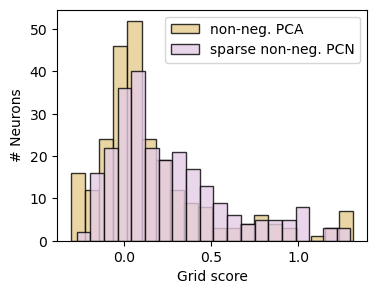

In [16]:
plt.figure(figsize=(4,3))
plt.hist(scores_pca, bins=20, alpha=0.8, label='non-neg. PCA', color='#E5CC8F', edgecolor='black')
plt.hist(scores_pcn, bins=20, alpha=0.8, label='sparse non-neg. PCN', color='#E5CCE5', edgecolor='black')
# # fit a kde to the histogram
# sns.kdeplot(scores_pca, color='#E5CC8F', linestyle='--')
# sns.kdeplot(scores_pcn, color='#E5CCE5', linestyle='--')
plt.xlabel('Grid score')
plt.ylabel('# Neurons')
plt.legend()
plt.savefig('figures/grid_score_hist.pdf', bbox_inches='tight')
plt.show()

In [25]:
def plot_gcs(rate_map, scores, save_name=None, nrow=3, ncol=4):
    fig, ax = plt.subplots(nrow, ncol, figsize=(ncol, nrow))
    for i, ax in enumerate(ax.flatten()):
        r = (rate_map[i] - rate_map[i].min()) / (rate_map[i].max() - rate_map[i].min())
        ax.imshow(r, cmap='jet')
        ax.axis('off')
        ax.set_title(f'{scores[i]:.2f}', fontsize=10)
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.5, right=0.8)
    plt.savefig(f'figures/{save_name}.pdf', bbox_inches='tight')
    plt.show()

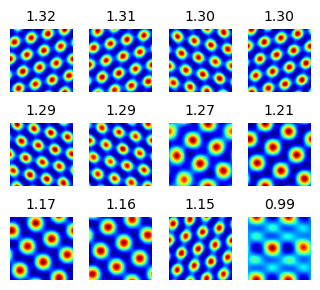

In [15]:
plot_gcs(gc_pca, scores_pca, 'pca_gcs')

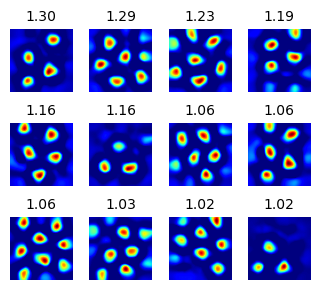

In [16]:
plot_gcs(gc_pcn, scores_pcn, 'pcn_gcs')

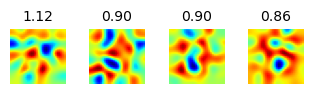

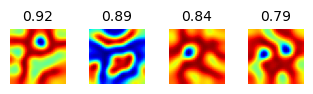

In [26]:
nosparse_path = 'results/pcn/sparse_False_relu_True'
norelu_path = 'results/pcn/sparse_True_relu_False'
gc_and_scores_nosparse = np.load(os.path.join(nosparse_path, 'gc_and_scores.npz'))
gcs_nosparse = gc_and_scores_nosparse['gcs']
scores_nosparse = gc_and_scores_nosparse['scores']

gc_and_scores_norelu = np.load(os.path.join(norelu_path, 'gc_and_scores.npz'))
gcs_norelu = gc_and_scores_norelu['gcs']
scores_norelu = gc_and_scores_norelu['scores']

plot_gcs(gcs_nosparse, scores_nosparse, 'nosparse_gcs', nrow=1, ncol=4)
plot_gcs(gcs_norelu, scores_norelu, 'norelu_gcs', nrow=1, ncol=4)

## Comparison between RNN and tPC

In [10]:
path_rnns = ["Jun-07-2024-22-03-53", "Jun-07-2024-22-20-31", "Jun-07-2024-22-36-13"]
path_pcns = ["May-08-2024-14-20-04", "Jun-08-2024-09-53-42", "Jun-08-2024-09-53-44"]
path_tbptt = ["Jun-11-2024-21-54-06", "Jun-15-2024-14-25-41", "Jun-15-2024-14-39-10"]

In [19]:
pos, pred_rnn, pred_tpc = get_trajetories(path_pcns[2], path_rnns[2])
plt.figure(figsize=(3, 3))
for i in range(3):
    plt.plot(pos[i, :, 0], pos[i, :, 1], 'k', linewidth=2.5, ls='--', label='Ground truth' if i == 0 else None)
    plt.plot(pred_rnn[i, :, 0], pred_rnn[i, :, 1], "#7c9d97", linewidth=2.5, label='RNN' if i == 0 else None)
    plt.plot(pred_tpc[i, :, 0], pred_tpc[i, :, 1], "#e9b383", linewidth=2.5, label='tPCN' if i == 0 else None)
    plt.xticks([])
    plt.yticks([])
    plt.xlim(-0.35, 0.7)
    plt.ylim(-0.35, 0.7)
plt.scatter(centers[:,0], centers[:,1], c='lightgrey', label='Place cell centers', s=3)
plt.legend(fontsize=9, loc='center left')
plt.tight_layout()
# plt.savefig('figures/trajectories_tpc_rnn.pdf', bbox_inches='tight')
plt.show()

RuntimeError: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx

In [9]:
def plot_gcs(rate_map, scores, save_name=None, nrow=3, ncol=4):
    fig, ax = plt.subplots(nrow, ncol, figsize=(ncol, nrow))
    for i, ax in enumerate(ax.flatten()):
        r = (rate_map[i] - rate_map[i].min()) / (rate_map[i].max() - rate_map[i].min())
        ax.imshow(r, cmap='jet')
        ax.axis('off')
        ax.set_title(f'{scores[i]:.2f}', fontsize=10)
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.5, right=0.8)
    plt.savefig(f'figures/{save_name}.pdf', bbox_inches='tight')
    plt.show()

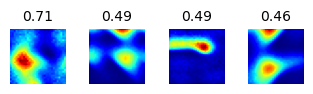

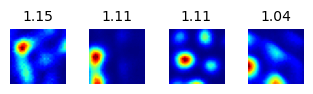

In [10]:
gcs_rnn = np.load(os.path.join('./results/rnn', path_rnns[2], 'top64_grid_cells.npy'))
gcs_tpc = np.load(os.path.join('./results/tpc', path_pcns[2], 'top64_grid_cells.npy'))
gcs_tbptt = np.load(os.path.join('./results/rnn', path_tbptt[0], 'top64_grid_cells.npy'))

scores_rnn = np.load(os.path.join('./results/rnn', path_rnns[2], 'grid_scores.npy'))
scores_tpc = np.load(os.path.join('./results/tpc', path_pcns[2], 'grid_scores.npy'))
scores_tbptt = np.load(os.path.join('./results/rnn', path_tbptt[0], 'grid_scores.npy'))

plot_gcs(gcs_rnn, scores_rnn, 'rnn_gcs_fast', nrow=1, ncol=4)
plot_gcs(gcs_tpc, scores_tpc, 'tpc_gcs_fast', nrow=1, ncol=4)

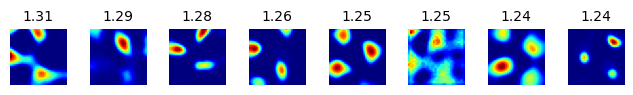

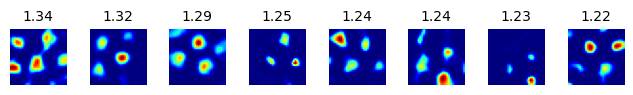

In [11]:
gcs_rnn = np.load(os.path.join('./results/rnn', path_rnns[0], 'top64_grid_cells.npy'))
gcs_tpc = np.load(os.path.join('./results/tpc', path_pcns[0], 'top64_grid_cells.npy'))
gcs_tbptt = np.load(os.path.join('./results/rnn', path_tbptt[0], 'top64_grid_cells.npy'))

scores_rnn = np.load(os.path.join('./results/rnn', path_rnns[0], 'grid_scores.npy'))
scores_tpc = np.load(os.path.join('./results/tpc', path_pcns[0], 'grid_scores.npy'))
scores_tbptt = np.load(os.path.join('./results/rnn', path_tbptt[0], 'grid_scores.npy'))

plot_gcs(gcs_rnn, scores_rnn, 'rnn_gcs_slow', nrow=1, ncol=8)
plot_gcs(gcs_tpc, scores_tpc, 'tpc_gcs_slow', nrow=1, ncol=8)
# plot_gcs(gcs_tbptt, scores_tbptt)

In [9]:
rnns = []
tpcs = []
tbptts = []
baselines = []
for i in range(3):
    errs_rnn = get_PI_performance(
        os.path.join('rnn', path_rnns[i]),
        model='rnn',
        verbose=(i == 2)
    )
    errs_tpc = get_PI_performance(
        os.path.join('tpc', path_pcns[i]),
        model='tpc',
        verbose=(i == 2)
    )
    errs_tbptt = get_PI_performance(
        os.path.join('rnn', path_tbptt[i]),
        model='rnn',
        verbose=(i == 2)
    )
    rnns.append(errs_rnn[0])
    tpcs.append(errs_tpc[0])
    tbptts.append(errs_tbptt[0])
    baselines.append([errs_rnn[1], errs_tpc[1], errs_tbptt[1]])

Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:00<00:00, 36.53it/s]

Initializing new model from scratch.
Get performance...



100%|██████████| 5/5 [00:01<00:00,  2.78it/s]


Initializing new model from scratch.
Get performance...


...

100%|██████████| 5/5 [00:00<00:00, 88.85it/s]


device: cuda
oned: False
Np: 512
Ng: 2048
Nv: 2
DoG: True
box_width: 1.4
box_height: 1.4
place_cell_rf: 0.12
surround_scale: 2
periodic: False
sequence_length: 10
dt: 0.1
batch_size: 500
n_epochs: 150
n_steps: 100
learning_rate: 0.0001
weight_decay: 0.0001
decay_step_size: 10
decay_rate: 0.9
lambda_z: 0
lambda_z_init: 0
inf_iters: 20
test_inf_iters: 20
inf_lr: 0.01
out_activation: softmax
rec_activation: relu
restore: None
preloaded_data: False
save: True
save_every: 50
loss: CE
normalize_pc: softmax
is_wandb: True
sweep: False
mode: train
no_velocity: False
truncating: 1
Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:01<00:00,  3.01it/s]


device: cuda
oned: False
Np: 512
Ng: 2048
Nv: 2
DoG: True
box_width: 1.4
box_height: 1.4
place_cell_rf: 0.12
surround_scale: 2
periodic: False
sequence_length: 10
dt: 0.1
batch_size: 500
n_epochs: 200
n_steps: 100
learning_rate: 0.0001
weight_decay: 0.0001
decay_step_size: 10
decay_rate: 0.9
lambda_z: 0
lambda_z_init: 0
inf_iters: 20
test_inf_iters: 20
inf_lr: 0.02
out_activation: softmax
rec_activation: relu
restore: None
preloaded_data: False
save: True
save_every: 100
loss: CE
normalize_pc: softmax
is_wandb: True
sweep: False
mode: train
no_velocity: False
truncating: 1
Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:00<00:00, 74.94it/s]


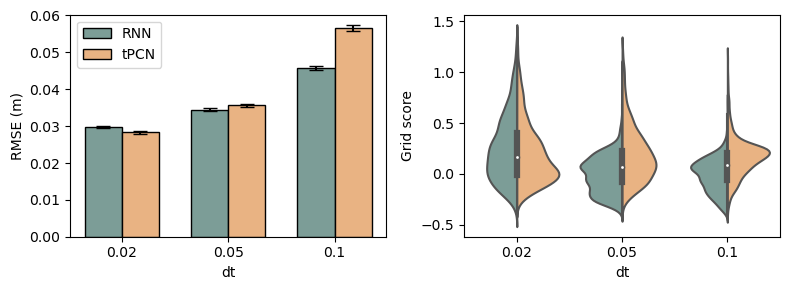

In [10]:
rnns = np.array(rnns)
tpcs = np.array(tpcs)
tbptts = np.array(tbptts)
baselines = np.array(baselines).reshape((3, -1)).mean(1)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Bar Plot
bar_width = 0.35
index = np.arange(len(rnns))

axes[0].bar(
    index - bar_width/2,
    rnns.mean(axis=1),
    bar_width,
    yerr=rnns.std(axis=1),
    label='RNN',
    color='#7c9d97',
    capsize=5,
    edgecolor='black',
    align='center',
)
axes[0].bar(
    index + bar_width/2,
    tpcs.mean(axis=1),
    bar_width,
    yerr=tpcs.std(axis=1),
    label='tPCN',
    color='#e9b383',
    capsize=5,
    edgecolor='black',
    align='center',
)

axes[0].set_xlabel('dt')
axes[0].set_ylabel('RMSE (m)')
axes[0].set_xticks(index)
axes[0].set_xticklabels(['0.02', '0.05', '0.1'])
axes[0].legend()

# Violin Plot
rnn_score = []
tpc_score = []
for i in range(3):
    rnn_score.append(np.load(os.path.join('./results/', 'rnn', path_rnns[i], 'grid_scores.npy')))
    tpc_score.append(np.load(os.path.join('./results/', 'tpc', path_pcns[i], 'grid_scores.npy')))
rnn_score = np.array(rnn_score)
tpc_score = np.array(tpc_score)

data = []
for i in range(3):
    for score in rnn_score[i]:
        data.append([i, 'RNN', score])
    for score in tpc_score[i]:
        data.append([i, 'TPC', score])

df = pd.DataFrame(data, columns=['Group', 'Type', 'Score'])
palette = {"RNN": "#7c9d97", "TPC": "#e9b383"}

sns.violinplot(
    x='Group',
    y='Score',
    hue='Type',
    data=df,
    split=True,
    inner="box",
    palette=palette,
    saturation=1.5,
    ax=axes[1],
    linecolor='black',
    legend=False
)

axes[1].set_xlabel('dt')
axes[1].set_ylabel('Grid score')
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['0.02', '0.05', '0.1'])
axes[1].legend([], frameon=False)

# Save the entire figure
plt.tight_layout()
plt.savefig('figures/combined_performance_grid_scores_rnn_tpc.pdf', bbox_inches='tight')
plt.show()

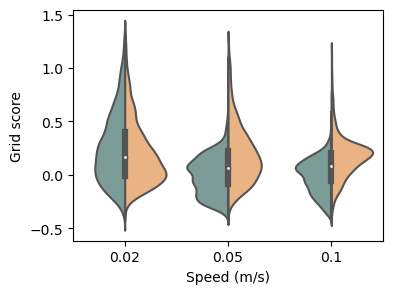

In [83]:
rnn_score = []
tpc_score = []
for i in range(3):
    rnn_score.append(np.load(os.path.join('./results/', 'rnn', path_rnns[i], 'grid_scores.npy')))
    tpc_score.append(np.load(os.path.join('./results/', 'tpc', path_pcns[i], 'grid_scores.npy')))
rnn_score = np.array(rnn_score)
tpc_score = np.array(tpc_score)

data = []
for i in range(3):
    for score in rnn_score[i]:
        data.append([i, 'RNN', score])
    for score in tpc_score[i]:
        data.append([i, 'TPC', score])

df = pd.DataFrame(data, columns=['Group', 'Type', 'Score'])
palette = {"RNN": "#7c9d97", "TPC": "#e9b383"}
# Plot
plt.figure(figsize=(4, 3))
v = sns.violinplot(
    x='Group', 
    y='Score', 
    hue='Type', 
    data=df, 
    split=True, 
    inner="box", 
    palette=palette,
    saturation=1.5,
    legend=False,
    linecolor='black',
)
v.get_legend().remove()
# plt.title('Paired Violin Plots')
plt.xlabel('Speed (m/s)')
plt.ylabel('Grid score')
plt.xticks([0,1,2], ['0.02', '0.05', '0.1'])
plt.savefig('figures/grid_scores_rnn_tpc.pdf', bbox_inches='tight')
plt.show()

## Comparison between with and without velocity inputs

In [7]:
path_v = os.path.join("tpc", "Jun-08-2024-09-51-30")
path_no_v = os.path.join("tpc", "Jun-09-2024-09-54-38")

In [8]:
errs_v, _ = get_PI_performance(path_v, repeats=5)

Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:01<00:00,  2.52it/s]


In [9]:
errs_no_v, baseline_errs = get_PI_performance(path_no_v, repeats=5)

Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:01<00:00,  3.21it/s]


In [10]:
scores_v = np.load(os.path.join('./results', path_v, 'grid_scores.npy'))
scores_no_v = np.load(os.path.join('./results', path_no_v, 'grid_scores.npy'))

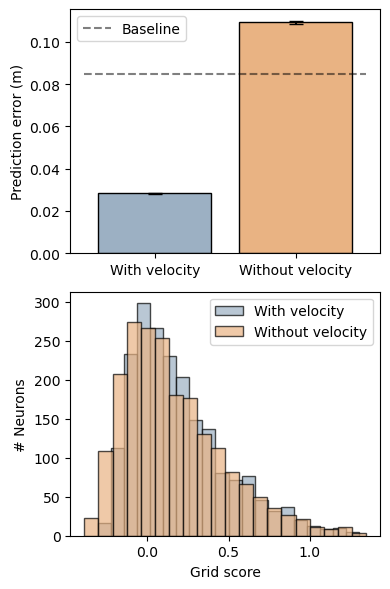

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(4, 6))

# Plot 1: Prediction error
axs[0].bar(
    ['With velocity', 'Without velocity'], 
    [np.mean(errs_v), np.mean(errs_no_v)], 
    yerr=[np.std(errs_v), np.std(errs_no_v)], 
    capsize=5,
    color=['#9cb0c3', '#e9b383'],
    edgecolor='black'
)
axs[0].hlines(
    np.mean(baseline_errs), 
    -0.5, 
    1.5, 
    color='k', 
    linestyles='dashed', 
    label='Baseline',
    alpha=0.5
)
axs[0].set_ylabel('Prediction error (m)')
axs[0].legend()

# Plot 2: Grid score histogram
axs[1].hist(scores_v, bins=20, alpha=0.7, label='With velocity', color='#9cb0c3', edgecolor='black')
axs[1].hist(scores_no_v, bins=20, alpha=0.7, label='Without velocity', color='#e9b383', edgecolor='black')
axs[1].legend()
axs[1].set_xlabel('Grid score')
axs[1].set_ylabel('# Neurons')

plt.tight_layout()
plt.show()


In [12]:
gcs_v = np.load(os.path.join('./results', path_v, 'top64_grid_cells.npy'))
gcs_no_v = np.load(os.path.join('./results', path_no_v, 'top64_grid_cells.npy'))

In [13]:
def plot_gcs(rate_map, scores):
    fig, ax = plt.subplots(4, 5, figsize=(5, 4))
    for i, ax in enumerate(ax.flatten()):
        r = (rate_map[i] - rate_map[i].min()) / (rate_map[i].max() - rate_map[i].min())
        ax.imshow(r, cmap='jet')
        ax.axis('off')
        ax.set_title(f'{scores[i]:.2f}', fontsize=10)
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.5, right=0.8)
    plt.show()

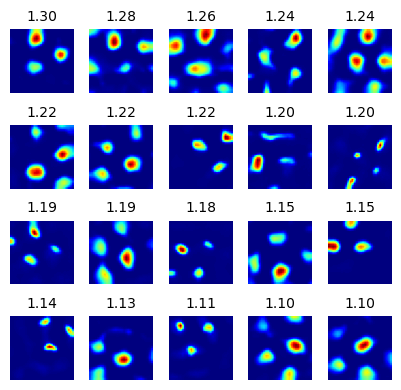

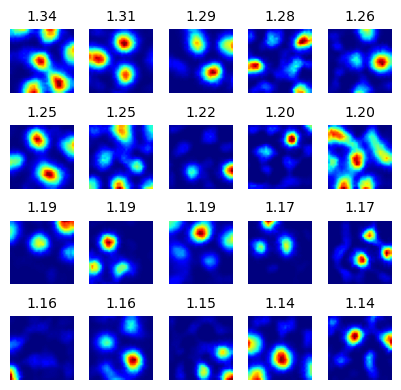

In [14]:
plot_gcs(gcs_v, scores_v)
plot_gcs(gcs_no_v, scores_no_v)

In [54]:
def get_trajectories_v(tpc1_path, tpc2_path):
    options_tpc1 = Options()
    options_tpc2 = Options()

    tpc1_path = os.path.join('./results', tpc1_path)
    options_tpc1.load_from_json(os.path.join(tpc1_path, 'configs.json'))
    ckpt_tpc1 = torch.load(os.path.join(tpc1_path, 'models', 'most_recent_model.pth'))
    options_tpc1.save_dir = tpc1_path

    tpc2_path = os.path.join('./results', tpc2_path)
    options_tpc2.load_from_json(os.path.join(tpc2_path, 'configs.json'))
    ckpt_tpc2 = torch.load(os.path.join(tpc2_path, 'models', 'most_recent_model.pth'))
    options_tpc2.save_dir = tpc2_path

    place_cell = PlaceCells(options_tpc1)
    generator = TrajectoryGenerator(options_tpc1, place_cell)

    tpc1 = TemporalPCN(options_tpc1).to(options_tpc1.device)
    init_model1 = HierarchicalPCN(options_tpc1).to(options_tpc1.device)
    tpc1.load_state_dict(ckpt_tpc1['model'])
    init_model1.load_state_dict(ckpt_tpc1['init_model'])
    pc_trainer1 = PCTrainer(options_tpc1, tpc1, init_model1, generator, place_cell, restore=False)

    tpc2 = TemporalPCN(options_tpc2).to(options_tpc2.device)
    init_model2 = HierarchicalPCN(options_tpc2).to(options_tpc2.device)
    tpc2.load_state_dict(ckpt_tpc2['model'])
    init_model2.load_state_dict(ckpt_tpc2['init_model'])
    pc_trainer2 = PCTrainer(options_tpc2, tpc2, init_model2, generator, place_cell, restore=False)

    # Generate trajectories (one batch)
    inputs, _, pos_batch = generator.get_test_batch()
    
    pred_tpc1, _ = pc_trainer1.predict(inputs)
    pred_tpc1 = place_cell.get_nearest_cell_pos(F.softmax(pred_tpc1.detach(), dim=-1)).detach().cpu().numpy()
    
    pred_tpc2, _ = pc_trainer2.predict(inputs)
    pred_tpc2 = place_cell.get_nearest_cell_pos(F.softmax(pred_tpc2.detach(), dim=-1)).detach().cpu().numpy()

    return pos_batch.detach().cpu().numpy(), pred_tpc1, pred_tpc2

Initializing new model from scratch.
Initializing new model from scratch.


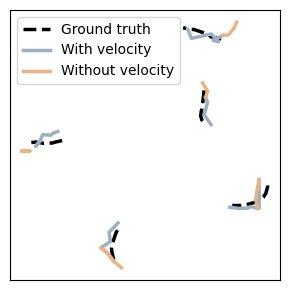

In [59]:
pos, pred_v, pred_no_v = get_trajectories_v(path_v, path_no_v)
plt.figure(figsize=(3, 3))
for i in range(5):
    plt.plot(pos[i, :, 0], pos[i, :, 1], 'k', linewidth=2.5, ls='--', label='Ground truth' if i == 0 else None)
    plt.plot(pred_v[i, :, 0], pred_v[i, :, 1], "#9cb0c3", linewidth=2.5, label='With velocity' if i == 0 else None)
    plt.plot(pred_no_v[i, :, 0], pred_no_v[i, :, 1], "#e9b383", linewidth=2.5, label='Without velocity' if i == 0 else None)
    plt.xticks([])
    plt.yticks([])
plt.legend()
plt.tight_layout()
plt.show()

## Robustness against multiple things
- nonlinearity
    - tanh (out): Jun-08-2024-09-42-09
    - tanh (rec): Jun-23-2024-15-55-56 
- env size
    - 1.8: Jun-11-2024-12-24-56
    - 1.2: Jun-23-2024-16-04-25
- model size
    - 256: Jun-11-2024-12-30-49
    - 512: Jun-16-2024-20-21-47
    - 1024: Jun-16-2024-20-21-54
- Gaussian PCs 
    - Gaussian: Jun-23-2024-15-55-14
- no velocity input:
    - Jun-09-2024-09-54-38

Overall, show in one violin plot of the grid scores and show in multiple panels the grid cell examples.

cmaps:
- Green_Orange_Teal
- Hiroshige
- Miller_Stone

In [35]:
base_path = os.path.join("tpc", "Jun-08-2024-09-51-30")
tanh_out_path = os.path.join("tpc", "Jun-08-2024-09-42-09")
tanh_rec_path = os.path.join("tpc", "Jun-23-2024-15-55-56")
big_env_path = os.path.join("tpc", "Jun-11-2024-12-24-56")
small_env_path = os.path.join("tpc", "Jun-23-2024-16-04-25")
gaussian_path = os.path.join("tpc", "Jun-23-2024-15-55-14")
small256_model_path = os.path.join("tpc", "Jun-11-2024-12-30-49")
small512_model_path = os.path.join("tpc", "Jun-16-2024-20-21-47")
small1024_model_path = os.path.join("tpc", "Jun-16-2024-20-21-54")
no_v_path = os.path.join("tpc", "Jun-09-2024-09-54-38")

errs_base, bl_base = get_PI_performance(base_path, repeats=5)
errs_tanh_out, bl_tanh_out = get_PI_performance(tanh_out_path, repeats=5)
errs_tanh_rec, bl_tanh_rec = get_PI_performance(tanh_rec_path, repeats=5)
errs_big_env, bl_big_env = get_PI_performance(big_env_path, repeats=5)
errs_small_env, bl_small_env = get_PI_performance(small_env_path, repeats=5)
errs_gaussian, bl_gaussian = get_PI_performance(gaussian_path, repeats=5)
errs_small256, bl_small256 = get_PI_performance(small256_model_path, repeats=5)
errs_small512, bl_small512 = get_PI_performance(small512_model_path, repeats=5)
errs_small1024, bl_small1024 = get_PI_performance(small1024_model_path, repeats=5)
errs_no_v, bl_no_v = get_PI_performance(no_v_path, repeats=5)

Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:01<00:00,  3.23it/s]


Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:00<00:00, 27.62it/s]


Initializing new model from scratch.
Get performance...


...

100%|██████████| 5/5 [00:01<00:00,  3.39it/s]


Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:01<00:00,  3.34it/s]


Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:01<00:00,  3.17it/s]


In [36]:
scores_base = np.load(os.path.join('./results', base_path, 'grid_scores.npy'))
scores_tanh_out = np.load(os.path.join('./results', tanh_out_path, 'grid_scores.npy'))
scores_tanh_rec = np.load(os.path.join('./results', tanh_rec_path, 'grid_scores.npy'))
scores_big_env = np.load(os.path.join('./results', big_env_path, 'grid_scores.npy'))
scores_small_env = np.load(os.path.join('./results', small_env_path, 'grid_scores.npy'))
scores_gaussian = np.load(os.path.join('./results', gaussian_path, 'grid_scores.npy'))
scores_small256 = np.load(os.path.join('./results', small256_model_path, 'grid_scores.npy'))
scores_small512 = np.load(os.path.join('./results', small512_model_path, 'grid_scores.npy'))
scores_small1024 = np.load(os.path.join('./results', small1024_model_path, 'grid_scores.npy'))
scores_no_v = np.load(os.path.join('./results', no_v_path, 'grid_scores.npy'))

In [37]:
#7992A6FF, #C0D1CEFF, #BCB584FF, #70684DFF, #383733FF

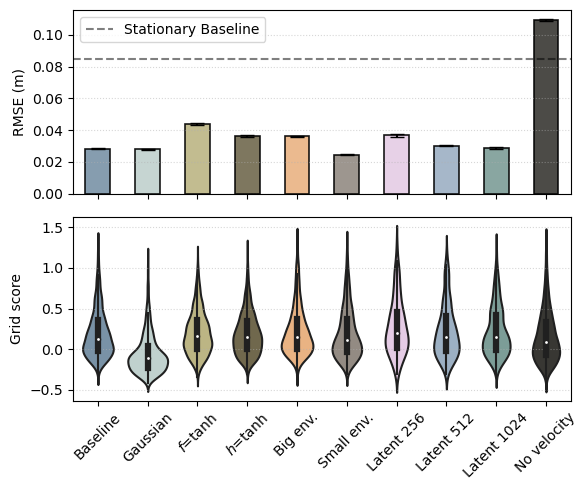

In [38]:
# colors = ['#693829FF', '#894B33FF', '#A56A3EFF', '#CFB267FF', '#D9C5B6FF', '#9CA9BAFF', '#5480B5FF', '#3D619DFF', '#405A95FF', '#345084FF]

# Prepare the categories and data for the plots
categories = ['Baseline', 'Gaussian', r'$f$=tanh', r'$h$=tanh', 'Big env.', 'Small env.', 
              'Latent 256', 'Latent 512', 'Latent 1024', 'No velocity']
scores = [scores_base, scores_gaussian, scores_tanh_out, scores_tanh_rec, scores_big_env, 
          scores_small_env, scores_small256, scores_small512, 
          scores_small1024, scores_no_v]

# First plot data (violin)
data = []
for category, score_array in zip(categories, scores):
    for score in score_array:
        data.append((category, score))
df_long = pd.DataFrame(data, columns=['Category', 'Grid score'])

# Second plot data (bar)
errors = [errs_base, errs_gaussian, errs_tanh_out, errs_tanh_rec, errs_big_env, errs_small_env, 
          errs_small256, errs_small512, errs_small1024, errs_no_v]
bls = [bl_base, bl_gaussian, bl_tanh_out, bl_tanh_rec, bl_big_env, bl_small_env,
       bl_small256, bl_small512, bl_small1024, bl_no_v]
means = [np.mean(err) for err in errors]
bl_means = [np.mean(bl) for bl in bls]
std_devs = [np.std(err) for err in errors]

# Color map
# cmap = load_cmap("Green_Orange_Teal")(np.linspace(0.1, 1, len(df_long['Category'].unique())))
cmap = mpl.colors.ListedColormap(
    ['#7992A6FF', '#C0D1CEFF', '#BCB584FF', '#70684DFF', '#E9B383FF', '#938B83', '#E5CCE5FF', '#9CB0C3FF', '#7C9D97FF', '#383733FF']
)
# Set up the subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 5), sharex=True)
plt.subplots_adjust(hspace=0.3)



# Second subplot (bar plot)
x = np.arange(len(categories))
axes[0].bar(x, means, yerr=std_devs, capsize=5, alpha=0.9, color=cmap.colors, width=0.5, edgecolor='black', linewidth=1.2)
axes[0].set_ylabel('RMSE (m)')
# axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0))
axes[0].grid(axis='y', ls=':', alpha=0.5)
# axes[0].set_title('Mean Prediction Errors with Standard Deviation')

axes[0].hlines(
    np.mean(bl_means), 
    -0.5, 
    9.5, 
    color='k', 
    linestyles='dashed', 
    label='Stationary Baseline',
    alpha=0.5
)
axes[0].legend()

# First subplot (violin plot)
sns.violinplot(
    x='Category', 
    y='Grid score', 
    data=df_long, 
    palette=cmap.colors, 
    # color="#e9b383",
    saturation=1,
    alpha=0.7,
    ax=axes[1]
)
# axes[1].set_title('Distribution of Grid Scores by Category')
axes[1].set_xlabel('')
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories, rotation=45)
axes[1].grid(axis='y', ls=':', alpha=0.5)
# axes[1].ticklabel_format(axis='y', style='sci', scilimits=(0,0))

# Display the plot
plt.tight_layout()
plt.savefig('figures/robustness.pdf', bbox_inches='tight')
plt.show()

In [51]:
def plot_gcs(rate_map, scores, save_name=None, nrow=3, ncol=4):
    fig, ax = plt.subplots(nrow, ncol, figsize=(ncol, nrow))
    for i, ax in enumerate(ax.flatten()):
        r = (rate_map[i] - rate_map[i].min()) / (rate_map[i].max() - rate_map[i].min())
        ax.imshow(r, cmap='jet')
        ax.axis('off')
        ax.set_title(f'{scores[i]:.2f}', fontsize=10)
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.5, right=0.8)
    plt.savefig(f'figures/{save_name}.pdf', bbox_inches='tight')
    plt.show()

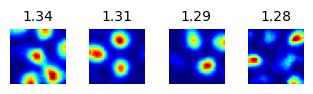

In [52]:
plot_gcs(gcs_no_v, scores_no_v, 'no_v_gcs', nrow=1, ncol=4)

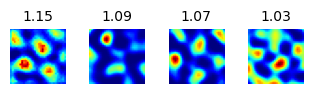

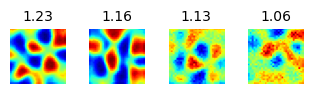

In [38]:
plot_gcs(gcs_tanh_out, scores_tanh_out, 'tanh_out_gcs', nrow=1, ncol=4)
plot_gcs(gcs_tanh_rec, scores_tanh_rec, 'tanh_rec_gcs', nrow=1, ncol=4)

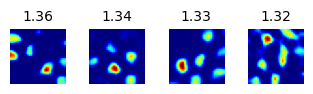

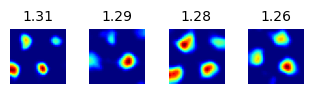

In [40]:
plot_gcs(gcs_big_env, scores_big_env, 'big_env_gcs', nrow=1, ncol=4)
plot_gcs(gcs_small_env, scores_small_env, 'small_env_gcs', nrow=1, ncol=4)

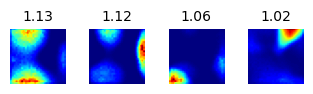

In [39]:
plot_gcs(gcs_gaussian, scores_gaussian, 'gaussian_gcs', nrow=1, ncol=4)

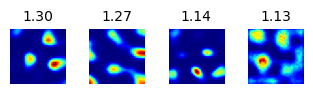

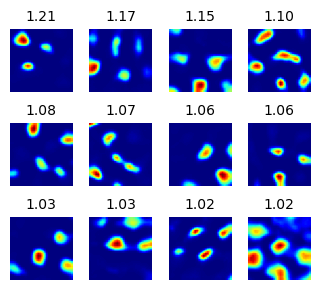

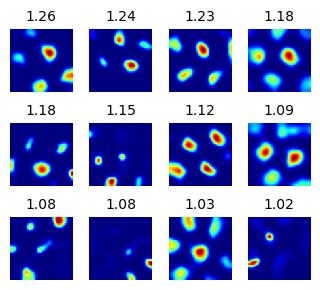

In [41]:
plot_gcs(gcs_small256_model, scores_small256_model, 'small256_model_gcs', nrow=1, ncol=4)
plot_gcs(gcs_small512_model, scores_small512_model, 'small512_model_gcs')
plot_gcs(gcs_small1024_model, scores_small1024_model, 'small1024_model_gcs')

## Comparison between tPC and TBPTT

1 infer iters: Jun-25-2024-14-07-36

5 infer iters: Jun-24-2024-17-10-53

10 infer iters: Jun-25-2024-07-21-52

50 infer iters: Jun-25-2024-07-20-24

In [31]:
path_tpc1 = os.path.join("tpc", "Jun-25-2024-14-07-36")
path_tpc5 = os.path.join("tpc", "Jun-24-2024-17-10-53")
path_tpc10 = os.path.join("tpc", "Jun-25-2024-07-21-52")
path_tpc20 = os.path.join("tpc", "Jun-08-2024-09-51-30")
path_tpc50 = os.path.join("tpc", "Jun-25-2024-07-20-24")
path_bptt = os.path.join("rnn", "Jun-07-2024-22-03-53")
path_tbptt = os.path.join("rnn", "Jun-11-2024-21-54-06")
paths = [path_tbptt, path_tpc1, path_tpc5, path_tpc10, path_tpc20, path_tpc50, path_bptt]

In [32]:
categories = ['tBPTT', 'tPCN1', 'tPCN5', 'tPCN10', 'tPCN20', 'tPCN50', 'BPTT']
errors = [get_PI_performance(path, model=('tpc' if "tpc" in path else 'rnn'), repeats=5)[0] for path in paths]

# Calculate mean and standard deviation for each set of errors
means = [np.mean(err) for err in errors]
std_devs = [np.std(err) for err in errors]

Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:00<00:00, 11.43it/s]


Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:01<00:00,  3.12it/s]


Initializing new model from scratch.
Get performance...


...

100%|██████████| 5/5 [00:01<00:00,  3.11it/s]


Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:01<00:00,  3.12it/s]


Initializing new model from scratch.
Get performance...


100%|██████████| 5/5 [00:00<00:00, 41.34it/s]


In [33]:
scores = [np.load(os.path.join('./results', path, 'grid_scores.npy')) for path in paths]

# Prepare the categories and data for the plots
categories = ['tBPTT', 'tPCN1', 'tPCN5', 'tPCN10', 'tPCN20', 'tPCN50', 'BPTT']
data = []
for category, score_array in zip(categories, scores):
    for score in score_array:
        data.append((category, score))
df_long = pd.DataFrame(data, columns=['Category', 'Grid score'])

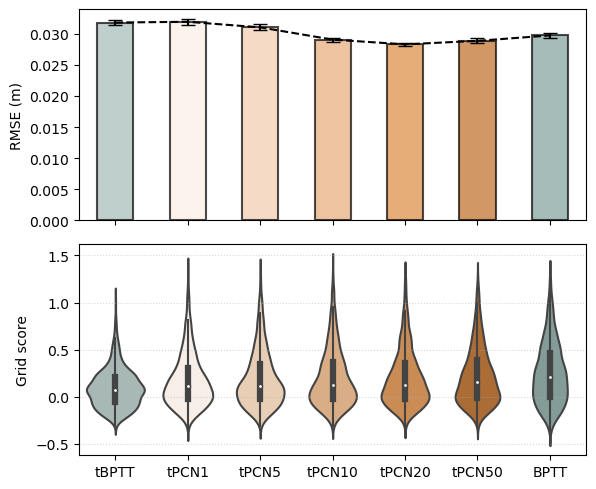

In [34]:
x = np.arange(len(categories))  # the label locations
# Apply color by category logic
colors = ['#a4bbb7', '#faeee4', '#f1cdae', '#e7ac78', '#dd8b41', '#be6b22', '#7fa09a']
# Set up the plot
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(6, 5), sharex=True)

# First subplot (bar plot)
axes[0].bar(x, means, yerr=std_devs, capsize=5, alpha=0.7, color=colors, width=0.5, edgecolor='black', linewidth=1.5)
axes[0].plot(x, means, color='black', alpha=1, ls='--', lw=1.5)
axes[0].set_ylabel('RMSE (m)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)

# Second subplot (violin plot)
axes[1].grid(axis='y', ls=':', alpha=0.5)
sns.violinplot(x='Category', y='Grid score', data=df_long, palette=colors, ax=axes[1])
axes[1].set_xlabel('')

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.3)

# Display the plot
plt.tight_layout()
plt.savefig('figures/tbptt.pdf', bbox_inches='tight')
plt.show()

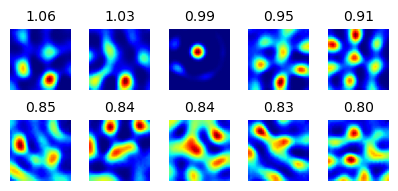

In [56]:
gcs_tbptt = np.load(os.path.join('./results', path_tbptt, 'top64_grid_cells.npy'))
scores_tbptt = np.load(os.path.join('./results', path_tbptt, 'grid_scores.npy'))
def plot_gcs(rate_map, scores, save_name=None, nrow=3, ncol=4):
    fig, ax = plt.subplots(nrow, ncol, figsize=(ncol, nrow))
    for i, ax in enumerate(ax.flatten()):
        r = (rate_map[i] - rate_map[i].min()) / (rate_map[i].max() - rate_map[i].min())
        ax.imshow(r, cmap='jet')
        ax.axis('off')
        ax.set_title(f'{scores[i]:.2f}', fontsize=10)
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.5, right=0.8)
    plt.savefig(f'figures/{save_name}.pdf', bbox_inches='tight')
    plt.show()
plot_gcs(gcs_tbptt, scores_tbptt, 'tbptt_gcs', nrow=2, ncol=5)